## Chuẩn bi dữ liệu

In [1]:
#Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Phase 1: Data Understanding

### 1.1 LOAD DỮ LIỆU

In [2]:
df = pd.read_csv('smartwatch.csv')
dfbackup = pd.read_csv('smartwatch.csv')

### 1.2 Describe Data (Mô tả dữ liệu)
Mục Tiêu:
- Kiểm tra số cột, dòng
- Biết tên của mỗi cột
- Biết kiểu dữ liệu của mỗi cột

In [3]:
print("Cấu trúc tổng quan của dữ liệu:")
df.info()
print("\n5 dòng đầu tiên của dữ liệu:")
df.head()

Cấu trúc tổng quan của dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  3607 non-null   str    
 1   condition              3607 non-null   str    
 2   Case_Size_mm           2729 non-null   float64
 3   Country                3607 non-null   str    
 4   price                  3607 non-null   float64
 5   Seller_ID              3607 non-null   str    
 6   Is_Worldwide_Shipping  3607 non-null   int64  
 7   title                  3607 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 225.6 KB

5 dòng đầu tiên của dữ liệu:


,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title
0,Garmin,Used,NaN,Japan,999.76,Seller_0001,1,Garmin fenix 7 Pro Sapphire Dual Power Watch 4...
1,Garmin,Used,NaN,Japan,928.00,Seller_0002,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...
2,Garmin,Used,50.0,Japan,934.92,Seller_0001,1,Garmin Fenix 7X Pro Solar Sapphire 50mm GPS Mu...
3,Garmin,New,NaN,Canada,1200.00,Seller_0003,0,garmin tactix 7 amoled edition BNIB
4,Garmin,Used,43.0,Japan,962.08,Seller_0001,1,Garmin Descent MK2S GPS Watch 43mm Light Sand ...


### Tổng quan dữ liệu & Nhận xét ban đầu

- **Cấu trúc dữ liệu:**
  Dataset gồm **3607 dòng và 8 cột**

- **Kiểu dữ liệu (Data Types):**
  - `brand`, `condition`, `Country`, `title`:
    Thuộc kiểu chuỗi (`object`) → phù hợp

  - `Seller_ID`:
    Cũng là kiểu chuỗi, tuy nhiên đây là **biến định danh (identifier)**
    Biến này **không mang ý nghĩa phân tích**, nên sẽ được **loại bỏ trong các bước tiếp theo**

  - `Case_Size_mm`, `price`:
    Là kiểu số thực (`float64`) → phù hợp cho phân tích định lượng
    Tuy nhiên, `Case_Size_mm` có **878 giá trị bị thiếu**, cần được xử lý

  - `Is_Worldwide_Shipping`:
    Hiện đang là kiểu số nguyên (`int64`) với giá trị 0/1, nhưng thực chất là **biến logic (Có/Không)**
    Do đó, nên chuyển sang kiểu **boolean** để dễ hiểu và phù hợp hơn

## 1.3. Explore Data
Mục tiêu là tìm xu hướng, phân phối và các dấu hiệu bất thường (như outliers)

- df.describe() : Cung cấp thống kê mô tả cho các cột số

In [4]:
df.describe()

,Case_Size_mm,price,Is_Worldwide_Shipping
count,2729.000000,3607.000000,3607.000000
mean,45.942836,617.819739,0.273357
std,3.165700,1071.008291,0.445745
min,26.000000,120.000000,0.000000
25%,44.000000,458.745000,0.000000
50%,46.000000,550.000000,0.000000
75%,49.000000,699.000000,1.000000
max,52.000000,49900.000000,1.000000


### Phân tích:
* `Case_Size_mm`: Missing 878 values(1/4 dữ liệu bị thiếu)
                    -> do tỉ lệ missing cao, biến này có thể không đáng tin cậy để sử dụng trong việc phân tích sâu hơn
* `Is_Worldwide_Shipping`: Giá trị min là 0, max là 1. Đây là một biến phân loại (categorical) đúng như mong đợi
* `price`: Có thể dễ dàng thấy được outlier max mang giá trị 49900, quá lớn so với các biến như mean và min
### Đổi kiểu biến:
Như đã đề cập, vai trò của biến Is_Worldwide_Shipping mang giá trị Có/Không nên việc đổi từ kiểu int64 một biến numeric sang boolen là điều cần thiết
Ngoài ra các biến như `brand`, `condition`, `Country` và `Seller_ID`, cũng nên được chuyển sang category để dễ phân loại

In [5]:
df['Is_Worldwide_Shipping'] = df['Is_Worldwide_Shipping'].astype('bool')

In [6]:
df['brand'] = df['brand'].astype('category')
df['condition'] = df['condition'].astype('category')
df['Country'] = df['Country'].astype('category')
df['Seller_ID'] = df['Seller_ID'].astype('category')
df['Is_Worldwide_Shipping'] = df['Is_Worldwide_Shipping'].astype('category')
print("Display structure of data after data type casting: \n")
df.info()

Display structure of data after data type casting: 

<class 'pandas.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   brand                  3607 non-null   category
 1   condition              3607 non-null   category
 2   Case_Size_mm           2729 non-null   float64 
 3   Country                3607 non-null   category
 4   price                  3607 non-null   float64 
 5   Seller_ID              3607 non-null   category
 6   Is_Worldwide_Shipping  3607 non-null   category
 7   title                  3607 non-null   str     
dtypes: category(5), float64(2), str(1)
memory usage: 119.9 KB


# Phase 2: Data Cleaning
### Data Imputation(Xử lý dữ liệu bị thiếu)
Mục tiêu: Điền dữ liệu vào cột Case_Size_mm, nếu không, vẽ biểu đồ sẽ gây thiếu chính xác
**Phương pháp điền**: Sử dụng giá trị mean

In [7]:
df['Case_Size_mm'] = df['Case_Size_mm'].fillna(df['Case_Size_mm'].median())

In [8]:
df.describe()

,Case_Size_mm,price
count,3607.000000,3607.000000
mean,45.956751,617.819739
std,2.753571,1071.008291
min,26.000000,120.000000
25%,45.000000,458.745000
50%,46.000000,550.000000
75%,49.000000,699.000000
max,52.000000,49900.000000


## 2.1 Verify Data Quaility
Mục tiêu
1. Kiểm tra dữ liệu thiếu (Missing values)
2. Kiểm tra trùng lặp(Duplicates)

In [9]:
# 1. Kiểm tra Missing Values
print("Tổng số giá trị thiếu (missing) cho mỗi cột:")
print(df.isnull().sum())

# 2. Kiểm tra Duplicates
print("\n\nTổng số hàng bị trùng lặp (duplicates):", df.duplicated().sum())



Tổng số giá trị thiếu (missing) cho mỗi cột:
brand                    0
condition                0
Case_Size_mm             0
Country                  0
price                    0
Seller_ID                0
Is_Worldwide_Shipping    0
title                    0
dtype: int64


Tổng số hàng bị trùng lặp (duplicates): 61


### Nhận xét:
1.  **(Missing)** Không có cột nào bị thiếu giá trị
2.  **(Duplicates)** Có 61 dữ liệu bị trùng lặp

## 2.2 Xử lý dữ liệu bị trùng
* **df.duplicated().sum()** để kiểm tra số dòng bị trùng
* **df[df.duplicated()]** hiển thị tất cả các dòng bị trùng lặp trong DataFrame
* **df = df.drop_duplicates()*** Chỉ giữ lại dòng đầu tiên xuất hiện, các dòng còn lại xóa




In [10]:
df.duplicated().sum()

np.int64(61)

In [11]:
df[df.duplicated()]

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title
145,Garmin,New,46.0,United States,938.38,Seller_0033,False,"Garmin Forerunner 970, Whitestone/Amp Yellow​​..."
197,Garmin,New,46.0,United States,899.95,Seller_0033,False,Garmin Fenix 7X Pro Solar Sapphire Edition Car...
239,Garmin,New,46.0,United States,889.95,Seller_0033,False,Garmin Fenix 7X Pro Sapphire Solar Edition Car...
326,Apple,Excellent - Refurbished,49.0,United States,839.95,Seller_0033,False,Apple Watch Ultra 2 [GPS + Cellular 49mm] Smar...
328,Apple,Excellent - Refurbished,49.0,United States,839.95,Seller_0033,False,Apple Watch Ultra 2 [GPS + Cellular 49mm] Smar...
...,...,...,...,...,...,...,...,...
3176,Apple,Used,45.0,United States,450.00,Seller_1551,False,Apple Watch Series 7 45mm Aluminum Case with S...
3179,Apple,Open box,49.0,United States,450.00,Seller_1270,False,"Apple Watch Ultra 2 49mm Titanium, GPS + Cellu..."
3191,Apple,Open box,49.0,United States,450.00,Seller_1270,False,"Apple Watch Ultra 2 49mm Titanium, GPS + Cellu..."
3220,Garmin,New,46.0,United States,449.99,Seller_0033,False,Garmin Venu 3S Soft Gold Stainless Steel Bezel...


In [12]:
df = df.drop_duplicates()

In [13]:
print("Sau khi xóa:")
print("\n\nTổng số hàng bị trùng lặp (duplicates):", df.duplicated().sum())

Sau khi xóa:


Tổng số hàng bị trùng lặp (duplicates): 0


# Phase 3: Univariate Analysis
Mục tiêu: phân tích đơn biến để đánh giá sự phân phối, tấn suất, tỉ lệ. Từ đó đưa ra những phán đoán và tìm ra nhưng Outliers

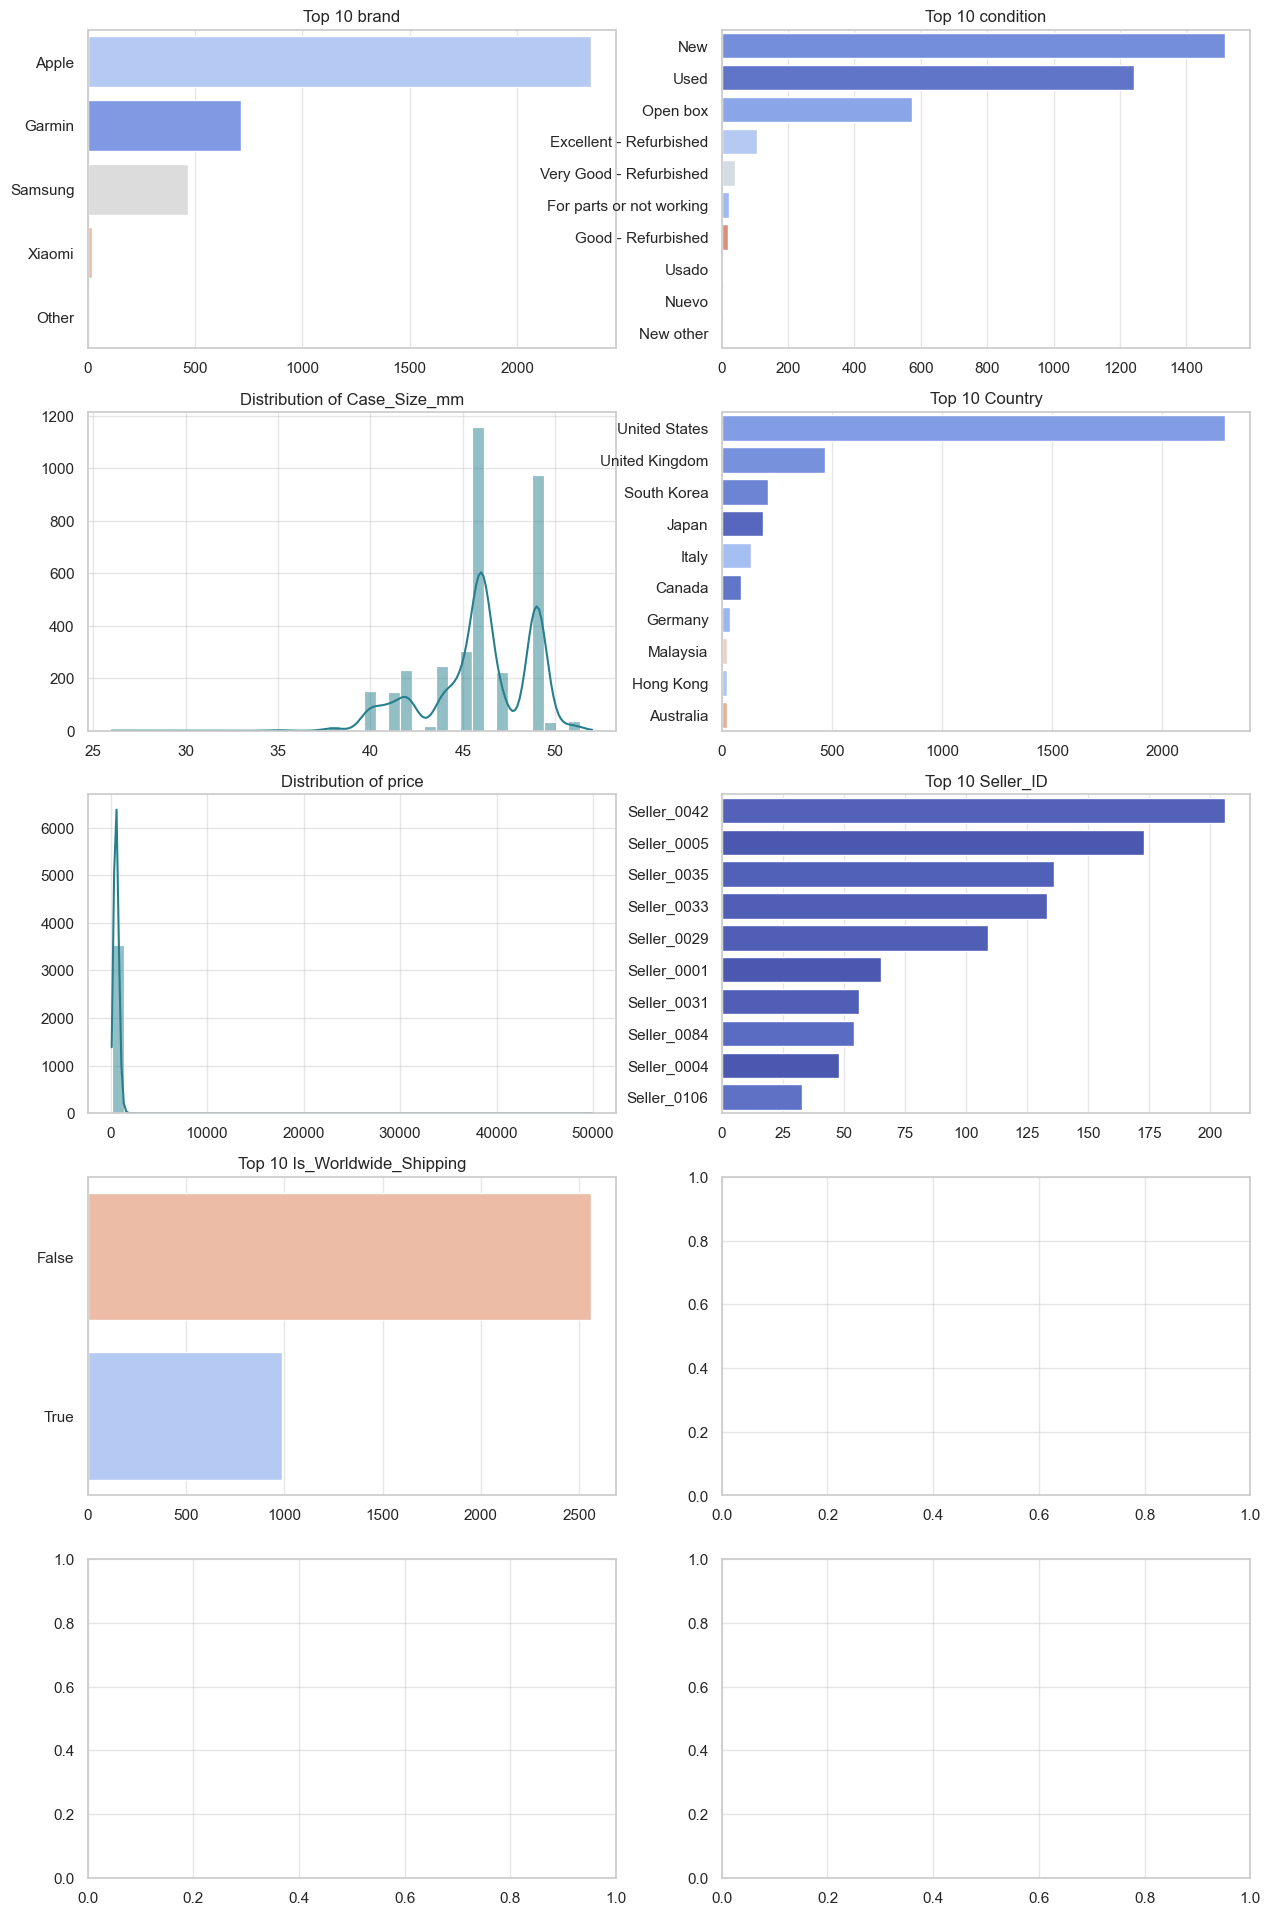

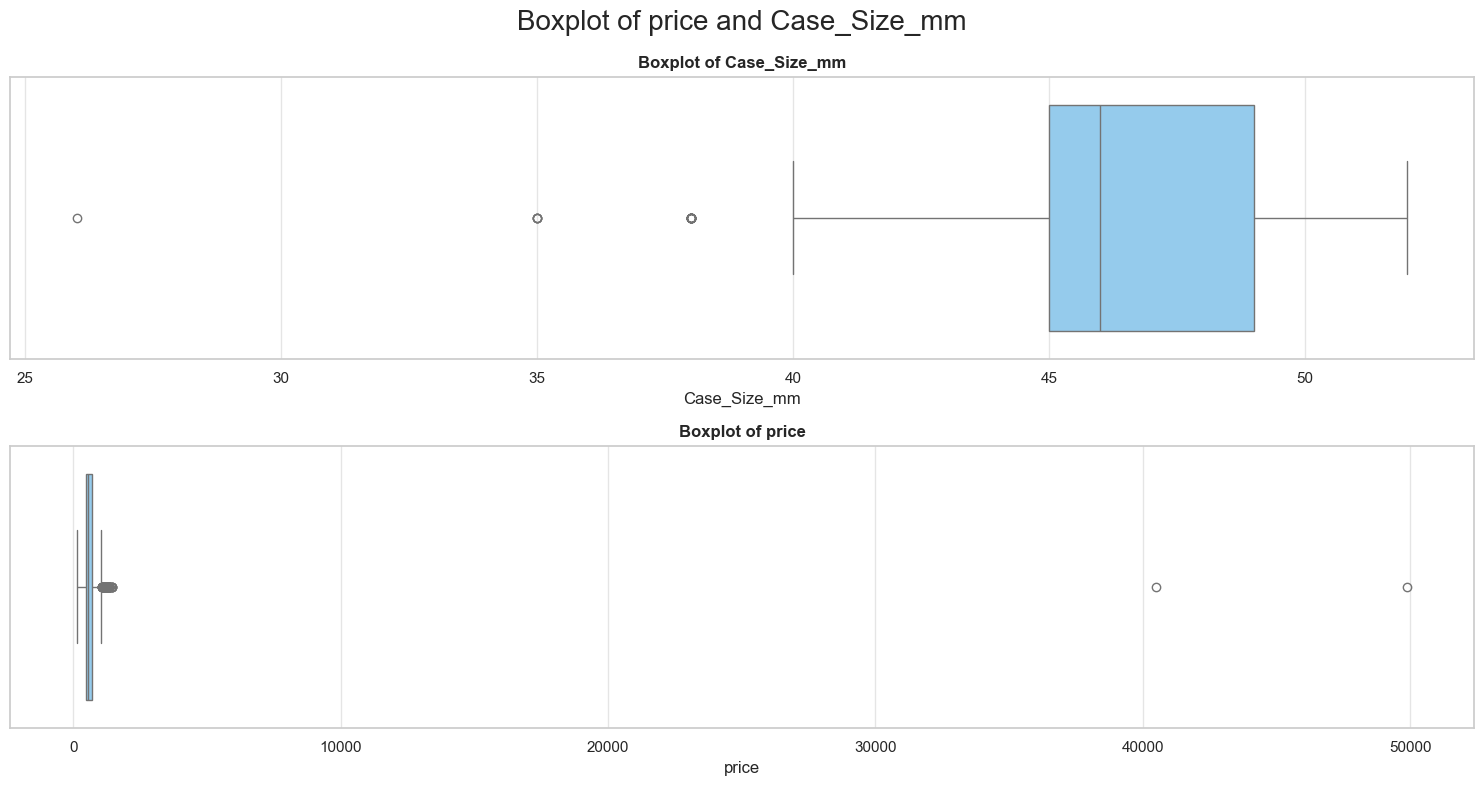

<Figure size 640x480 with 0 Axes>

In [14]:


# ======================
# STYLE
# ======================
sns.set_theme(style="whitegrid")
sns.set_palette("pastel")

fig, axes = plt.subplots(5, 2, figsize=(15, 24))
axes = axes.flatten()

cols_to_plot = [
    'brand',
    'condition',
    'Case_Size_mm',
    'Country',
    'price',
    'Seller_ID',
    'Is_Worldwide_Shipping'
]

# ======================
# 1. DISTRIBUTION LOOP
# ======================
for i, col in enumerate(cols_to_plot):

    if col not in df.columns:
        axes[i].set_title(f"{col} not found")
        continue

    # numeric
    if df[col].dtype in ['int64', 'float64']:

        sns.histplot(
            df[col],
            bins=40,
            kde=True,
            ax=axes[i],
            color=sns.color_palette("viridis")[2]
        )

        axes[i].set_title(f"Distribution of {col}")

    # categorical
    else:

        df[col] = df[col].astype(str)

        top_10 = df[col].value_counts().head(10).index

        sns.countplot(
            y=col,
            data=df,
            order=top_10,
            hue=col,
            palette="coolwarm",
            legend=False,
            ax=axes[i]
        )

        axes[i].set_title(f"Top 10 {col}")

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# 5. Vẽ Boxplot cho các biến số để xác định Outliers
num_cols = ['Case_Size_mm', 'price']
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color='lightskyblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
fig.suptitle('Boxplot of price and Case_Size_mm', fontsize=20)
plt.tight_layout()
plt.show()

# ======================
# FINAL TOUCH
# ======================
plt.suptitle("EDA: Distribution + Boxplot", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.1 Phân tích phân phối dữ liệu
- `Brand`: Apple 2200 áp đảo, Garmin 600, Samsung 300, còn lại rất ít
- `Condition`: New 1400 và Used 1100 chiếm đa số, Open box 500, Refurbished rất ít
- `Case Size`: Tập trung 46–49mm, phân phối đa đỉnh, ít dưới 40mm hoặc trên 50mm
- `Price`: Lệch phải mạnh, chủ yếu giá thấp, outlier tới 50000
- `Country`: US 2200 chiếm đa số, UK 400, các nước khác ít
- `Seller`: Tập trung vào vài seller lớn, `Seller_0042` dẫn đầu 200
- `Shipping`: False 72% chiếm đa số, True 28%

- `Case_Size_mm`: Kích thước case tập trung chủ yếu trong khoảng 44–50 mm, median khoảng 46.5 mm. Phân bố khá đối xứng và ổn định, IQR hẹp cho thấy 50% dữ liệu nằm trong khoảng 44.5–49 mm. Chỉ có một số outlier nhỏ khoảng 26 mm, 35 mm và 38 mm, trong khi phía giá trị lớn hầu như không có ngoại lai

- `Price`: Phân phối lệch phải rất mạnh, đa số giá trị nằm ở mức thấp gần 0 nên boxplot rất hẹp. Một số ít giá trị kéo đuôi phân bố sang phải, với outlier cao từ khoảng 38000 đến 50000, cho thấy chênh lệch lớn giữa sản phẩm phổ thông và cao cấp

## 3.2.1 Xử lý Outliers của `Price`
bằng phương pháp IQR

In [15]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# outliers
outliers = df[(df['price'] < lower) | (df['price'] > upper)]

# dataset sau khi xóa outliers
df_clean = df[(df['price'] >= lower) & (df['price'] <= upper)]

# ======================
# PRINT RESULTS
# ======================
print("IQR Outlier Analysis - PRICE")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

print("=======================")
print("Số outliers:", len(outliers))

print("=======================")

print("Shape ban đầu:", df.shape)
print("Shape sau khi xóa:", df_clean.shape)
print("Số dòng đã xóa:", df.shape[0] - df_clean.shape[0])

IQR Outlier Analysis - PRICE
Q1: 457.06
Q3: 699.0
IQR: 241.94
Lower bound: 94.15000000000003
Upper bound: 1061.9099999999999
Số outliers: 60
Shape ban đầu: (3546, 8)
Shape sau khi xóa: (3486, 8)
Số dòng đã xóa: 60


## 3.2.2 Xử lý Outliers của `Case_Size_mm`
Trước tiên hãy kiểm tra xem các outliers của `Case_Size_mm` trông như thế nào

In [16]:
Q1 = df['Case_Size_mm'].quantile(0.25)
Q3 = df['Case_Size_mm'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# lấy outliers
outliers_case = df[(df['Case_Size_mm'] < lower) | (df['Case_Size_mm'] > upper)]




print("\n Số outliers:", len(outliers_case))


print("\nCác giá trị outlier bị trùng:")

dup_values = outliers_case['Case_Size_mm'].value_counts()

print(dup_values)


 Số outliers: 24

Các giá trị outlier bị trùng:
Case_Size_mm
38.0    19
35.0     4
26.0     1
Name: count, dtype: int64


Từ đây, có thể kết luận được rằng không nhất thiết phải xóa các Outliers của `Case_Size_mm` vì số outliers = 24 so với >3600 của dataset là quá nhỏ đồng nghĩa với việc đây có thể là giá trị thật, có ý nghĩa.

# Phase 4: Multivariate Analysis
Trong case này chúng ta sẽ phân tích mối quan hệ giữa 2 biến chính là `price` và `Case_Size_mm` bằng biểu đồ Scatter Plot

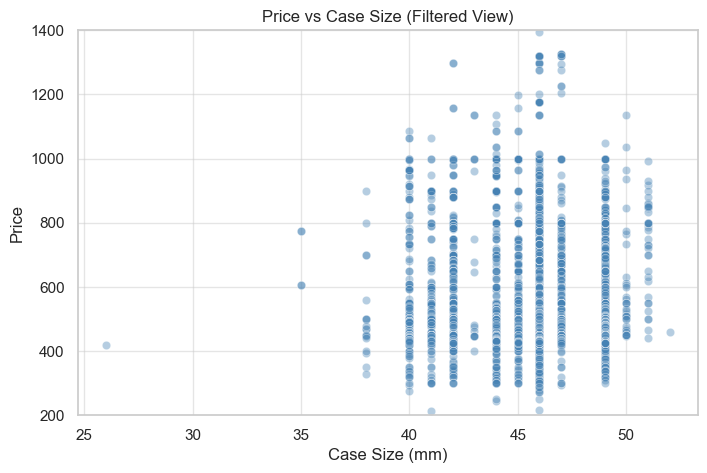

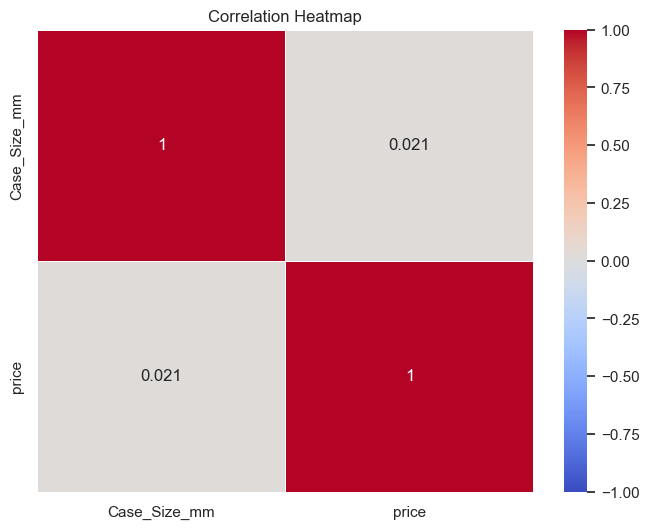

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Case_Size_mm',
    y='price',
    data=df,
    alpha=0.4,
    color='steelblue'
)

plt.title("Price vs Case Size (Filtered View)")
plt.xlabel("Case Size (mm)")
plt.ylabel("Price")

#  giới hạn trục Y
plt.ylim(200, 1400)

plt.show()
num_df = df.select_dtypes(include=['int64', 'float64'])

corr = num_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

###  1. Correlation Heatmap
Hệ số tương quan giữa `Case_Size_mm` và `price` chỉ khoảng **0.021**, gần như bằng 0.
 -> Điều này cho thấy **không tồn tại mối quan hệ tuyến tính đáng kể** giữa kích thước case và giá sản phẩm.
### 2. Scatter Plot (Price vs Case Size)
- Các điểm dữ liệu phân bố rải rác, không hình thành xu hướng rõ ràng (không tăng hoặc giảm theo kích thước case).
- Giá tập trung chủ yếu trong khoảng **200 – 1400**, trong khi Case Size chủ yếu nằm trong khoảng **40 – 52 mm**.
- Một số giá trị cao hơn xuất hiện ở vùng **45–48 mm**, tuy nhiên không tạo ra xu hướng tổng thể rõ ràng.
### Tóm tắt
 Hai biến gần như **không có tương quan tuyến tính**, cho thấy **Case_Size_mm không phải yếu tố quan trọng ảnh hưởng đến Price** trong dataset này.

4.2 Mối quan hệ giữa các biến phân loại

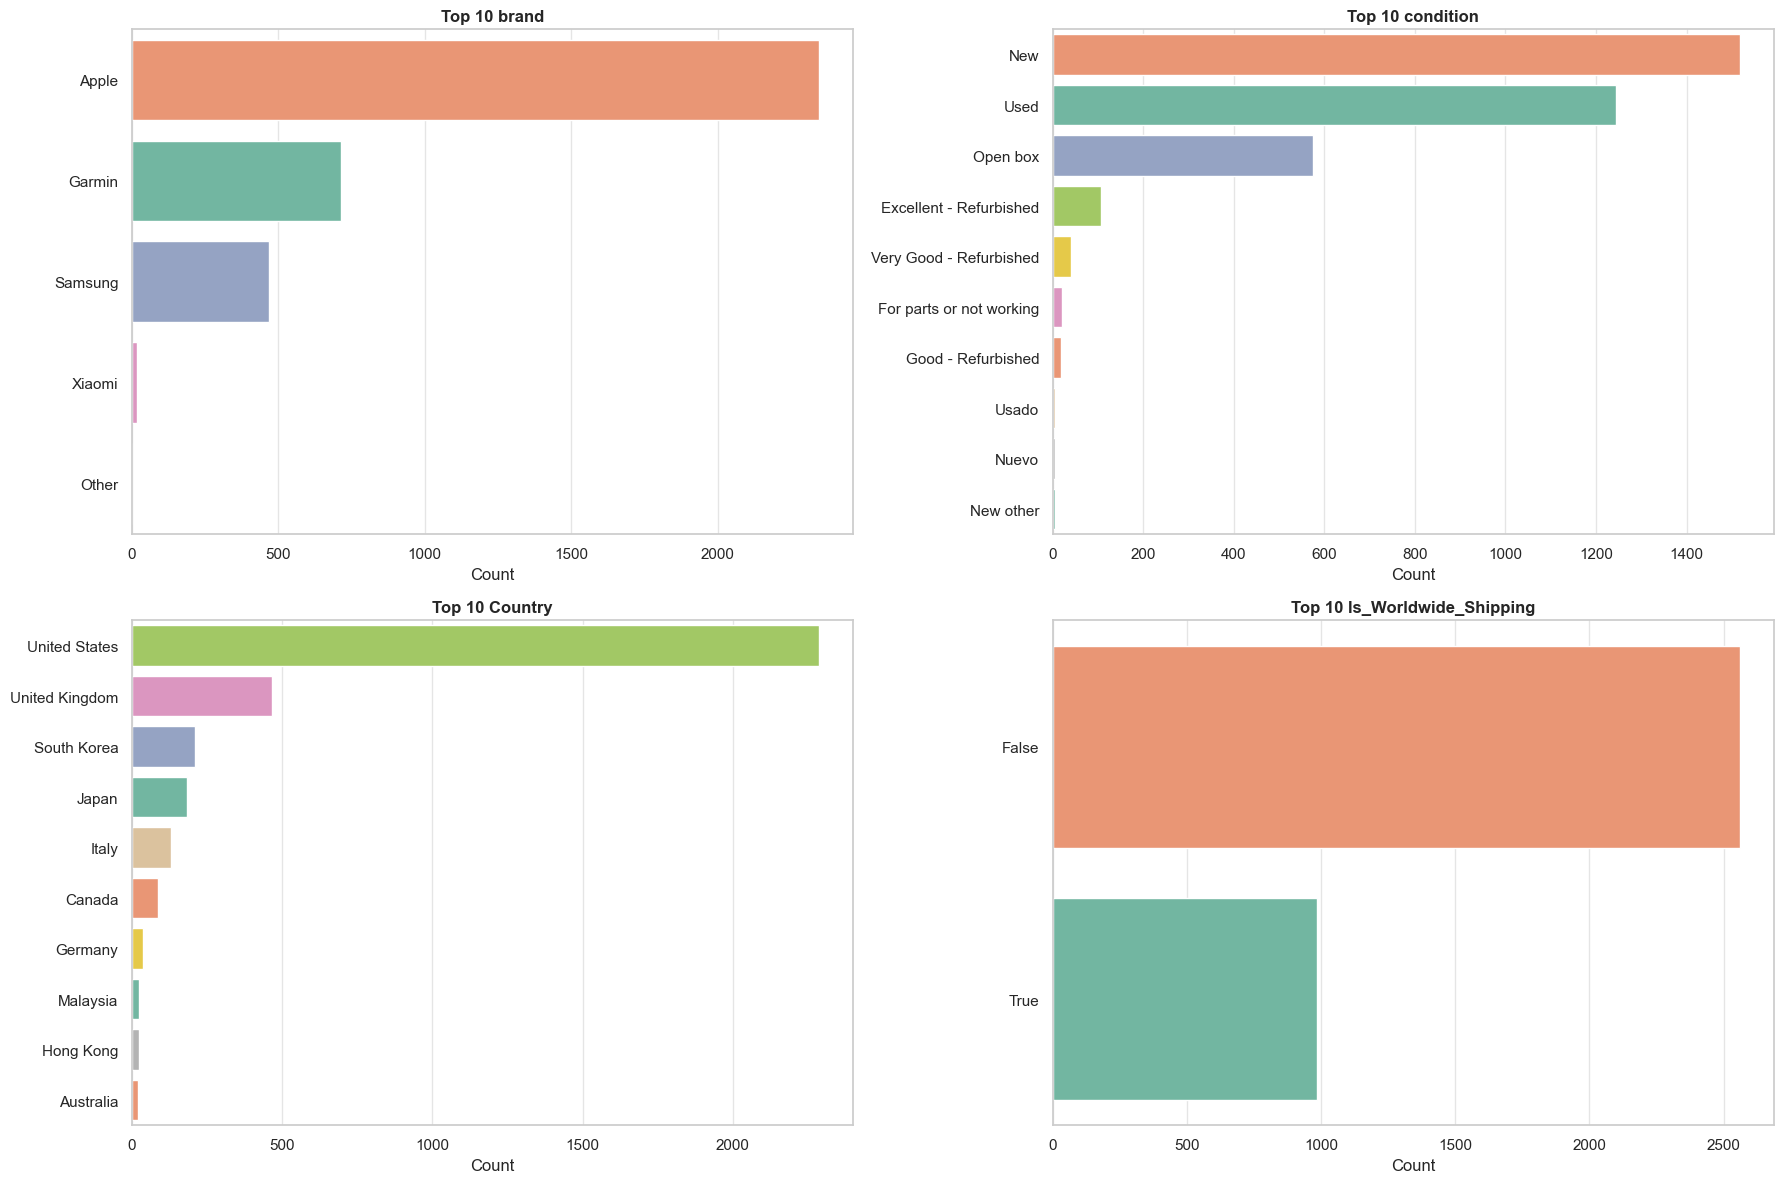

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ======================
# 1. COLUMNS
# ======================
cat_cols = ['brand', 'condition', 'Country', 'Is_Worldwide_Shipping']

# ======================
# 2. FIGURE
# ======================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# ======================
# 3. LOOP
# ======================
for i, col in enumerate(cat_cols):

    # lấy top 10 giá trị
    top_vals = df[col].value_counts().nlargest(10).index
    df_top = df[df[col].isin(top_vals)]

    sns.countplot(
        data=df_top,
        y=col,
        order=top_vals,
        hue=col,            # FIX WARNING
        palette='Set2',
        legend=False,       # tắt legend
        ax=axes[i]
    )

    axes[i].set_title(f"Top 10 {col}", fontweight='bold')
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

B### Phân tích:
- Tops
Apple chiếm ưu thế tuyệt đối với hơn 2200 sản phẩm.
Garmin đứng thứ hai với khoảng 700 sản phẩm.
Samsung đứng thứ ba với khoảng 450 sản phẩm.
Xiaomi và các brand khác chiếm tỷ lệ rất nhỏ → thị trường bị Apple thống trị rõ rệt.
- Condition (Tình trạng sản phẩm)
New chiếm tỷ lệ lớn nhất khoảng 1400 sản phẩm.
Used đứng thứ hai khoảng 1200 sản phẩm.
Open box khoảng 600 sản phẩm.
Refurbished và các trạng thái khác chiếm tỷ lệ rất thấp.
-  Country (Quốc gia)
United States chiếm đa số với khoảng 2300 sản phẩm.
United Kingdom đứng thứ hai khoảng 450 sản phẩm.
Các quốc gia còn lại như South Korea, Japan, Italy chiếm tỷ lệ nhỏ.
-  Is_Worldwide_Shipping
False chiếm đa số với khoảng 2500 sản phẩm.
True chỉ khoảng 1000 sản phẩm.
##  Tóm tắt chung
Dữ liệu tập trung chủ yếu vào Apple, sản phẩm mới/đã qua sử dụng, thị trường Mỹ, và phần lớn không hỗ trợ giao hàng toàn cầu. Thị trường có mức độ tập trung cao vào một số thương hiệu và quốc gia chính.

# Feature Engineering

In [19]:
df = df.drop(columns=["Seller_ID"])

In [20]:
df["title"].head(10)
df["title"].tail(10)

3597    Apple Watch series 11 42mm GPS Black BRAND NEW...
3598    Apple Watch Series 7 45mm Midnight Al Case Spo...
3599    Garmin Forerunner 165 Music Smartwatch Smart w...
3600    Apple Watch Series 10 (GPS) 46mm Al Case with ...
3601         Garmin Vivoactive 6 - 42 mm - Slate / Black-
3602    Apple Watch Series 10 42mm Rose Gold Aluminum,...
3603    Apple Watch Series 10 46mm GPS Cellular RoseGo...
3604    Apple Watch Series 11 Titanium 46mm (GPS + Cel...
3605    Apple Watch Ultra 2 49mm Titanium Case - Blue/...
3606    Samsung Galaxy Watch Ultra 47mm Silver Titaniu...
Name: title, dtype: str

In [21]:
import re

def extract_caseSize(title):
    p = re.compile(r"(\d+)\s*mm", re.IGNORECASE)
    match = p.search(title)
    return int(match.group(1)) if match else None


In [22]:
df["case_size_mm"] = df["title"].astype(str).apply(extract_caseSize)

In [23]:
title = "Apple Watch Ultra 2 49mm Titanium Case - Blue/Black, 49mm - Excellent"
print(extract_caseSize(title))

49


In [24]:
df["case_size_mm"].isna().sum()

np.int64(853)

In [25]:
df["case_size_mm"] = df["title"].apply(extract_caseSize)

In [26]:
df[df["case_size_mm"].isna()]["title"].head(20)

1     Garmin Descent Mk1 Dive Computer Smartwatch GP...
3                   garmin tactix 7 amoled edition BNIB
5     Garmin Descent Mk1 Dive Computer Smartwatch GP...
6     Garmin Venu X1 Black Smartwatch GPS Multisport...
8             Garmin Epix GPS Porsche Design Smartwatch
9     Garmin Tacx FLUX S Smart Direct Drive Trainer ...
10    GARMIN FENIX 7X PRO Watch Multi-sport GPS Sapp...
12         Apple Watch Ultra 2 Used with Optional Strap
14    Garmin Fenix 7X Sapphire Dual Power Ti GPS Sma...
20          MacBook, Watch, iPad and pro pencil  Bundle
21      Apple Watch Ultra 3  Titanium  With Statos Band
23    Apple Watch Series 4 44m Aluminium Space Gray ...
30    Apple Watch Series 10 GPS Jet Black Brand New ...
31    GARMIN Cycle Computer Palm Sized Yellow Cyclin...
33                          Hermès Single Tour Series 6
34                                   Hermes Apple Watch
37    Garmin Edge1040 Solar GPS Cycling Computer wit...
39    iPhones All Different Series Watches Earpo

In [27]:
known_brands = ["apple", "garmin", "samsung", "xiaomi", "huawei"]

def extract_brand(title):
    title = str(title).lower()
    for b in known_brands:
        if b in title:
            return b.capitalize()
    return "Other"

df["brand"] = df["title"].apply(extract_brand)

In [28]:
brands = ["Apple", "Garmin", "Samsung", "Xiaomi", "Huawei"]

def extract_brand(title):
    for b in brands:
        if b.lower() in str(title).lower():
            return b
    return "Other"

df["brand"] = df["title"].apply(extract_brand)
print(brands)


['Apple', 'Garmin', 'Samsung', 'Xiaomi', 'Huawei']


In [29]:
df["case_size_mm"] = pd.to_numeric(df["case_size_mm"], errors="coerce")

df["case_size_mm"] = df.groupby("brand")["case_size_mm"] \
    .transform(lambda x: x.fillna(x.median()))

In [30]:
global_median = df["case_size_mm"].median()

df["case_size_mm"] = df.groupby("brand")["case_size_mm"] \
    .transform(lambda x: x.fillna(x.median() if not pd.isna(x.median()) else global_median))

In [31]:
df["case_size_mm"].isna().sum()

np.int64(0)

In [32]:
df["condition"].unique()

<StringArray>
[                    'Used',                      'New',
                 'Open box', 'For parts or not working',
  'Excellent - Refurbished',             'Caja abierta',
  'Very Good - Refurbished',                    'Usado',
  'Certified - Refurbished',                    'Nuevo',
                'New other',       'Good - Refurbished',
                     'Novo',                       '--']
Length: 14, dtype: str

In [33]:
def clean_condition(x):
    if pd.isna(x):
        return "unknown"

    x = x.lower()

    if "new" in x or "nuevo" in x or "novo" in x:
        return "new"

    elif "used" in x or "usado" in x:
        return "used"

    elif "refurb" in x:
        return "refurbished"

    elif "open box" in x or "caja abierta" in x:
        return "open_box"

    elif "parts" in x or "not working" in x:
        return "broken"

    else:
        return "other"

df["condition_clean"] = df["condition"].apply(clean_condition)

In [34]:
df["condition_clean"].value_counts()

condition_clean
new            1528
used           1249
open_box        577
refurbished     170
broken           21
other             1
Name: count, dtype: int64

In [35]:
def map_region(x):
    if x in ["United States", "Canada"]:
        return "north_america"

    elif x in ["United Kingdom", "Germany", "Italy"]:
        return "europe"

    elif x in ["Japan", "South Korea", "Malaysia", "Hong Kong"]:
        return "asia"

    elif x in ["Australia"]:
        return "oceania"

    else:
        return "other"

df["region"] = df["Country"].apply(map_region)

In [36]:
df["region"].value_counts()

region
north_america    2372
europe            635
asia              446
other              70
oceania            23
Name: count, dtype: int64

In [37]:
df["condition"].unique()

<StringArray>
[                    'Used',                      'New',
                 'Open box', 'For parts or not working',
  'Excellent - Refurbished',             'Caja abierta',
  'Very Good - Refurbished',                    'Usado',
  'Certified - Refurbished',                    'Nuevo',
                'New other',       'Good - Refurbished',
                     'Novo',                       '--']
Length: 14, dtype: str

In [38]:
df["condition"] = df["condition"].str.lower().str.strip()

In [39]:
def normalize_condition(x):
    if pd.isna(x):
        return "other"

    x = x.lower().strip()

    if "new" in x or "nuevo" in x or "novo" in x:
        return "new"

    if "open box" in x or "caja abierta" in x:
        return "open_box"

    if "refurbished" in x:
        return "refurbished"

    if "used" in x or "usado" in x:
        return "used"

    if "parts" in x or "--" in x:
        return "broken"

    return "other"

In [40]:
df["condition_clean"] = df["condition"].apply(normalize_condition)

In [41]:
df["condition_clean"].value_counts()

condition_clean
new            1528
used           1249
open_box        577
refurbished     170
broken           22
Name: count, dtype: int64

In [42]:
condition_map = {
    "new": 4,
    "open_box": 3,
    "refurbished": 2,
    "used": 1,
    "broken": 0,
    "other": 0
}

df["condition_score"] = df["condition_clean"].map(condition_map)

In [43]:
df["condition_score"] = df["condition_score"].fillna(0)

In [44]:
df = df.drop(columns=["condition", "condition_clean"])

In [45]:
df[["condition_score", "price"]].corr()

,condition_score,price
condition_score,1.000000,0.025865
price,0.025865,1.000000


In [46]:
df["Country"].unique()


<StringArray>
[         'Japan',         'Canada',    'South Korea', 'United Kingdom',
  'United States',         'Greece',        'Germany',          'Italy',
      'Hong Kong',         'Poland',        'Belgium',    'Netherlands',
          'Spain',         'Israel', 'Estados Unidos',       'Malaysia',
        'Ireland',    'Reino Unido',         'France',      'Australia',
         'Italia',      'Lithuania',        'Hungary',          'China',
        'Unknown',  'Corea del Sur',         'Latvia']
Length: 27, dtype: str

In [47]:
df["Country"] = df["Country"].str.lower().str.strip()

In [48]:
def normalize_country(x):
    if pd.isna(x):
        return "unknown"

    x = x.lower().strip()

    if x in ["united states", "estados unidos"]:
        return "us"

    if x in ["united kingdom", "reino unido"]:
        return "uk"

    if x in ["south korea", "corea del sur"]:
        return "korea"

    if x in ["italy", "italia"]:
        return "italy"

    if x in ["spain"]:
        return "spain"

    if x in ["hong kong"]:
        return "hong_kong"

    if x in ["unknown"]:
        return "unknown"

    return x

In [49]:
df["country_clean"] = df["Country"].apply(normalize_country)

In [50]:
df["country_clean"].value_counts()

country_clean
us             2295
uk              469
korea           213
japan           185
italy           132
canada           87
germany          37
malaysia         25
hong_kong        24
australia        23
poland           14
israel           14
france            8
china             5
netherlands       3
spain             3
greece            2
ireland           2
belgium           1
lithuania         1
hungary           1
unknown           1
latvia            1
Name: count, dtype: int64

In [51]:
df = pd.get_dummies(df, columns=["country_clean"])

In [52]:
# ====== FIX BRAND ======
df["brand"] = df["brand"].str.lower().str.strip()

brand_counts = df["brand"].value_counts()

rare = brand_counts[brand_counts < 50].index
df["brand"] = df["brand"].replace(rare, "other")

df["brand_condition"] = df["brand"] + "_" + df["condition_score"].astype(str)

In [53]:
# tách data
X = df.drop(columns=["price"])
y = np.log1p(df["price"])
# encode
X = pd.get_dummies(X)

# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=25,
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)


model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.23275964838927593
R2: 0.389165111299826


In [55]:
import pandas as pd

feat = pd.Series(model.feature_importances_, index=X.columns)
print(feat.sort_values(ascending=False).head(10))

title_Smartwatch (2025) SAMSUNG Galaxy Watch Ultra 47mm versão LTE SM-L705U lacrado-    0.086297
Country_united kingdom                                                                  0.080094
title_Apple Watch Ultra 2 49mm Titânio, Azul/Preto, TL M/L, Desbloqueado-               0.076212
Is_Worldwide_Shipping_False                                                             0.053048
region_asia                                                                             0.042357
Is_Worldwide_Shipping_True                                                              0.037275
Case_Size_mm                                                                            0.037084
case_size_mm                                                                            0.036021
condition_score                                                                         0.030948
brand_condition_apple_4                                                                 0.023619
dtype: float64


In [56]:
(df["Case_Size_mm"] != df["case_size_mm"]).sum()

np.int64(443)

In [57]:
df[["Case_Size_mm", "case_size_mm"]].isna().sum()

Case_Size_mm    0
case_size_mm    0
dtype: int64

In [58]:
df[["Case_Size_mm", "case_size_mm"]].corr()

,Case_Size_mm,case_size_mm
Case_Size_mm,1.000000,0.786869
case_size_mm,0.786869,1.000000


In [59]:
df = df.drop(columns=["Case_Size_mm"])

In [60]:
df = df.drop(columns=["title"])

In [61]:
# tách data
X = df.drop(columns=["price"])
y = np.log1p(df["price"])
# encode
X = pd.get_dummies(X)

# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=25,
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)


model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.23697653994107665
R2: 0.3668317083859519


In [62]:
df = df.drop(columns=["region"])

In [63]:
# tách data
X = df.drop(columns=["price"])
y = np.log1p(df["price"])
# encode
X = pd.get_dummies(X)

# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=25,
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)


model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.2356902021176077
R2: 0.37368688320774524
